# **Marine Protected Area (MPA) Analyzer — Sri Lanka**

## Project Overview
This notebook performs a geospatial analysis of MPAs
around Sri Lanka. Using GeoPandas and supporting libraries, we delineate
maritime zones (territorial sea and EEZ), load designated MPA boundaries from
the World Database on Protected Areas (WDPA), and conduct spatial analysis to
determine MPA coverage across Sri Lanka's marine jurisdiction.

## Data Sources
- Natural Earth — country boundaries (naturalearthdata.com)
- GADM — high resolution Sri Lanka boundary (gadm.org)
- WDPA — Marine Protected Areas (protectedplanet.net)

## Libraries Used
- geopandas — spatial data handling and analysis
- matplotlib — static map visualization
- folium — interactive map visualization
- shapely — geometric operations
- pandas — tabular data handling
- numpy — numerical operations


In [2]:
# Install Libraries

!pip install geopandas -q # Core library for spatial data
!pip install folium -q # Interactive map rendering
!pip install requests -q # Wdpa data handler (to fetch MPA data)

#Import Libraries

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shapely.geometry import Point, Polygon, MultiPolygon # Create and manipulate individual geometry objects

import folium # Interactive map rendering in the browser
import os
import requests # Fetch data from web APIs (used for WDPA data)
import warnings # Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Create Output Directories

# Create a folder structure to store outputs neatly
# os.makedirs creates the folder if it doesn't already exist
os.makedirs('data', exist_ok=True)       # for saved GeoJSON files
os.makedirs('outputs', exist_ok=True)   # for saved map images

# Confirm Setup


print("Environment Setup Completed.")

print(f"  GeoPandas: {gpd.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Folium: {folium.__version__}")

print("All libraries imported successfully.")
print("Output directories created.")

Environment Setup Complete
  GeoPandas: 1.1.3
  Pandas: 2.2.2
  NumPy: 2.0.2
  Folium: 0.20.0
All libraries imported successfully
Output directories created


##Loading Sri Lanka's High Resolution Boundary

Loading Sri Lanka's administrative boundary from the Global
Administrative Areas database (GADM).

GADM provides high resolution boundary data at multiple administrative levels. We use Level 0 (national boundary) which represents the full country outline including the coastline.

This boundary serves as the foundation for all subsequent spatial operations
including maritime zone delineation and MPA overlap analysis.

- Source  : GADM v4.1 (gadm.org)
- CRS     : EPSG:4326 (WGS84 Geographic Coordinate System)
- Level   : 0 (National boundary)

Raw data loaded successfully.
Shape     : (1, 3)
CRS       : EPSG:4326
Columns   : ['GID_0', 'COUNTRY', 'geometry']

Geometry type : ['MultiPolygon']
Total bounds  : [79.5218  5.9185 81.8788  9.8357]

Cleaned columns : ['COUNTRY', 'geometry']


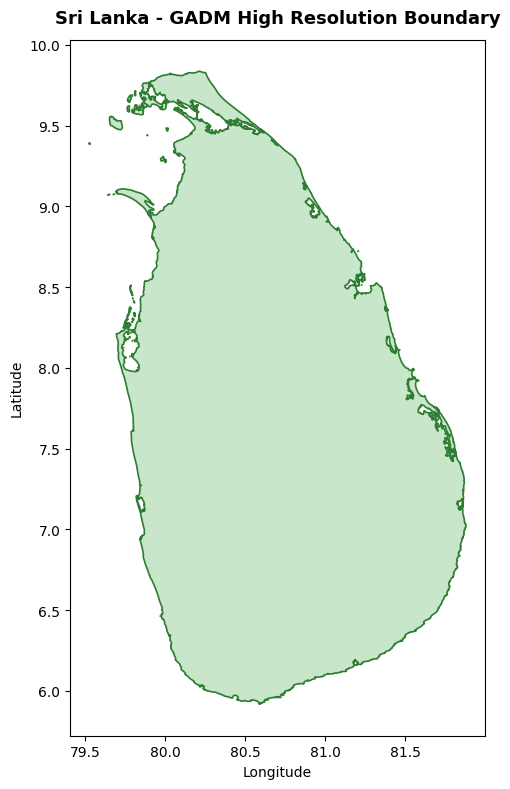


Boundary verification plot saved to outputs.
  Country       : SriLanka
  Geometry type : MultiPolygon
  CRS           : EPSG:4326
  Bounds (lon)  : 79.5218 to 81.8788
  Bounds (lat)  : 5.9185 to 9.8357


In [5]:

# Input: GADM GeoJSON URL for Sri Lanka (Level 0)
# Output: sri_lanka (GeoDataFrame) - single polygon of Sri Lanka

# GADM naming convention: gadm41_LKA_0.json
#   gadm41  - GADM version 4.1
#   LKA     - ISO 3166-1 alpha-3 country code for Sri Lanka
#   0       - Administrative level (0 = national boundary)


# Load Sri Lanka boundary from GADM
# gpd.read_file() can read directly from a URL - no manual download needed
url_gadm = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_0.json"
sri_lanka = gpd.read_file(url_gadm)

print("Raw data loaded successfully.")
print(f"Shape     : {sri_lanka.shape}")
print(f"CRS       : {sri_lanka.crs}")
print(f"Columns   : {sri_lanka.columns.tolist()}")


# Inspect the geometry
# geom_type tells if Sri Lanka is a Polygon or MultiPolygon
print(f"\nGeometry type : {sri_lanka.geom_type.values}")
print(f"Total bounds  : {sri_lanka.total_bounds}")
# total_bounds returns (minLon, minLat, maxLon, maxLat)
# this is the bounding box that wraps around the entire country


# Keep only essential columns
# GADM comes with many metadata columns we do not need
# geometry must always be kept - it contains the shape data
sri_lanka = sri_lanka[['COUNTRY', 'geometry']]
print(f"\nCleaned columns : {sri_lanka.columns.tolist()}")


# Verify the boundary looks correct
# A quick plot confirms the shape loaded correctly before we proceed
fig, ax = plt.subplots(figsize=(6, 8))

sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',      # light green fill
    edgecolor='#2e7d32',  # dark green border
    linewidth=1.2
)

ax.set_title(
    'Sri Lanka - GADM High Resolution Boundary',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)

plt.tight_layout()

# Save the verification plot to outputs folder
plt.savefig('outputs/01_sri_lanka_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBoundary verification plot saved to outputs.")


print(f"  Country       : {sri_lanka['COUNTRY'].values[0]}")
print(f"  Geometry type : {sri_lanka.geom_type.values[0]}")
print(f"  CRS           : {sri_lanka.crs}")
print(f"  Bounds (lon)  : {sri_lanka.total_bounds[0]:.4f} to {sri_lanka.total_bounds[2]:.4f}")
print(f"  Bounds (lat)  : {sri_lanka.total_bounds[1]:.4f} to {sri_lanka.total_bounds[3]:.4f}")

## Maritime Zone Delineation

Maritime zones are defined under the United Nations Convention on the Law of
the Sea (UNCLOS). This section delineates two primary zones around Sri Lanka:

Territorial Sea (TS):
- Extends 12 nautical miles (22,224 m) from the baseline (coastline).
- Sri Lanka exercises full sovereignty within this zone.

Exclusive Economic Zone (EEZ):
- Extends 200 nautical miles (370,400 m) from the baseline.
- Sri Lanka holds exclusive rights to marine resources within this zone.

Methodology
- The boundary geometry is reprojected from EPSG:4326 to EPSG:32644 (UTM Zone 44N) prior to buffering. This is mandatory because buffer distances must be specified in meters, and EPSG:4326 uses degrees.
- Post-buffering, geometries are reprojected back to EPSG:4326 for consistency and visualization.

Unit Conversion:
- 1 nautical mile = 1,852 meters
- 12  nm = 22,224  m (Territorial Sea)
- 200 nm = 370,400 m (Exclusive Economic Zone)

Unit conversions defined.
  Territorial Sea : 12 nm = 22,224 m
  EEZ             : 200 nm = 370,400 m

Reprojected to  : EPSG:32644

Territorial Sea created.
  Geometry type : Polygon
  Bounds        : [79.3195  5.7175 82.08   10.0367]

EEZ created.
  Geometry type : Polygon
  Bounds        : [76.1553  2.5681 85.2255 13.1852]

EEZ Ring (outer zone) created.

Zone Areas
  Sri Lanka land area : 65,793 km2
  Territorial Sea     : 97,918 km2
  Full EEZ            : 910,935 km2

Zone files saved to data.




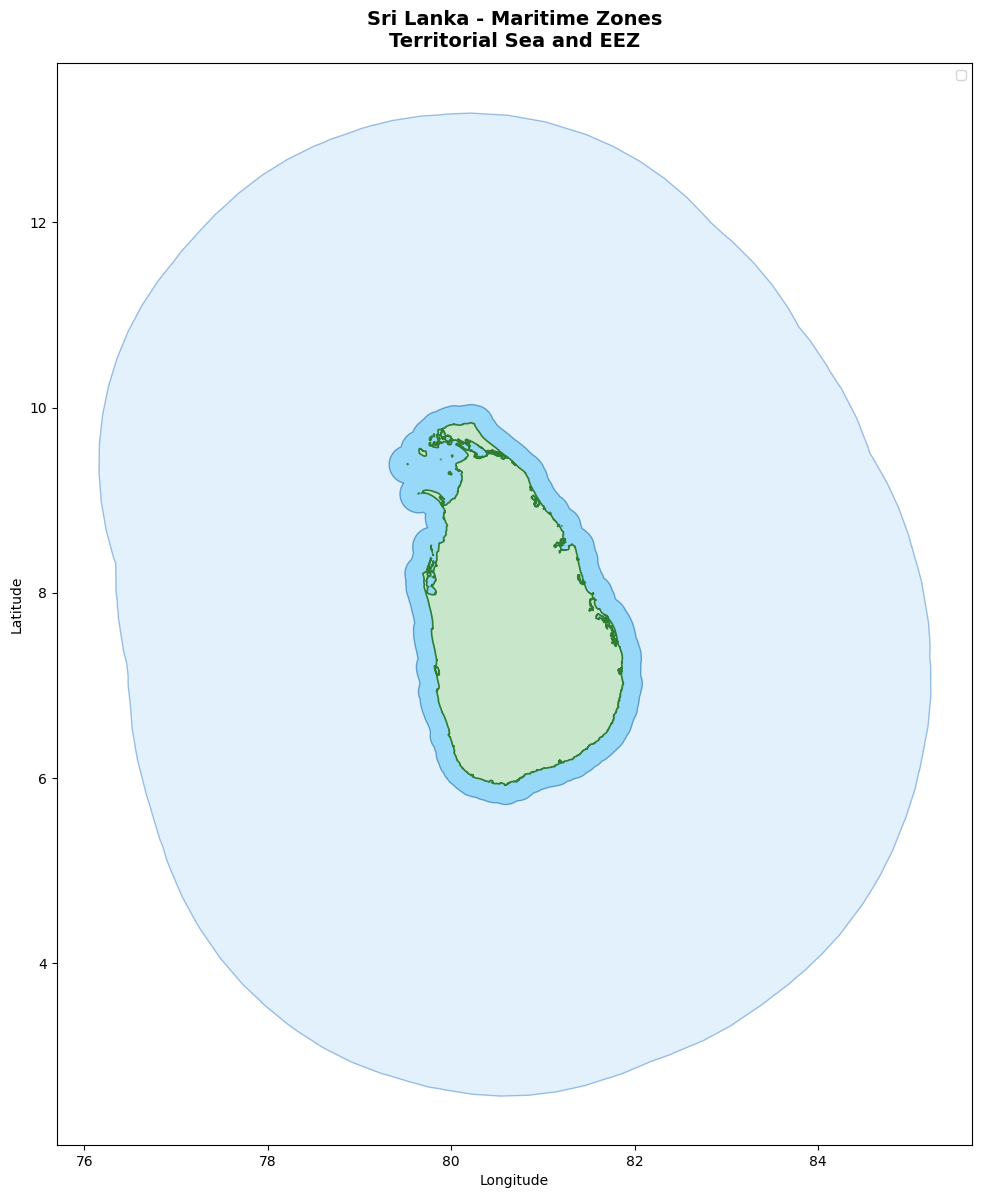



Maritime zones map saved to outputs.
  Territorial Sea area: 97,918 km2
  Full EEZ area: 910,935 km2
  Files saved: 3 GeoJSON files in data


In [10]:
# Input: sri_lanka (GeoDataFrame) - national boundary from Section 2
# Output: territorial_sea (GeoDataFrame) - 12nm zone

# eez (GeoDataFrame) - 200nm zone
# eez_ring (GeoDataFrame) - EEZ minus territorial sea


# Define nautical mile conversions
# All buffer operations require metric units (meters)
# We define these as constants for clarity and reusability

NM_TO_METERS = 1852          # 1 nautical mile in meters

TERRITORIAL_SEA_NM = 12      # UNCLOS Article 3
TERRITORIAL_SEA_M  = TERRITORIAL_SEA_NM * NM_TO_METERS   # 22,224 m

EEZ_NM = 200                 # UNCLOS Article 57
EEZ_M  = EEZ_NM * NM_TO_METERS                           # 370,400 m

print("Unit conversions defined.")
print(f"  Territorial Sea : {TERRITORIAL_SEA_NM} nm = {TERRITORIAL_SEA_M:,} m")
print(f"  EEZ             : {EEZ_NM} nm = {EEZ_M:,} m")


# Reproject to UTM Zone 44N (EPSG:32644)
# Buffer distances must be in meters - EPSG:4326 uses degrees
# UTM Zone 44N is the correct projected CRS for Sri Lanka's region
# After reprojection, coordinates are in meters

sri_lanka_utm = sri_lanka.to_crs(epsg=32644)
print(f"\nReprojected to  : {sri_lanka_utm.crs}")


# Create the Territorial Sea (12nm buffer)
# .buffer() expands the geometry outward by the specified distance in meters
# The result is a new polygon that includes the land + 12nm of ocean

ts_utm = sri_lanka_utm.copy()
ts_utm['geometry'] = sri_lanka_utm.geometry.buffer(TERRITORIAL_SEA_M)
ts_utm['zone'] = 'Territorial Sea (12nm)'

# Reproject back to EPSG:4326 for consistency with other layers
territorial_sea = ts_utm.to_crs(epsg=4326)
print("\nTerritorial Sea created.")
print(f"  Geometry type : {territorial_sea.geom_type.values[0]}")
print(f"  Bounds        : {territorial_sea.total_bounds.round(4)}")


# Create the EEZ (200nm buffer)
# Same process but with a larger distance
# This polygon includes land + territorial sea + EEZ combined

eez_utm = sri_lanka_utm.copy()
eez_utm['geometry'] = sri_lanka_utm.geometry.buffer(EEZ_M)
eez_utm['zone'] = 'Exclusive Economic Zone (200nm)'

# Reproject back to EPSG:4326
eez = eez_utm.to_crs(epsg=4326)
print("\nEEZ created.")
print(f"  Geometry type : {eez.geom_type.values[0]}")
print(f"  Bounds        : {eez.total_bounds.round(4)}")


# Create the EEZ Ring (EEZ minus Territorial Sea)
# The full EEZ buffer includes the territorial sea area inside it
# For visualization and analysis we want just the outer ring
# .difference() subtracts one geometry from another

eez_ring_utm = eez_utm.copy()
eez_ring_utm['geometry'] = eez_utm.geometry.difference(
    ts_utm.geometry.values[0]   # subtract territorial sea from full EEZ
)
eez_ring_utm['zone'] = 'EEZ Outer Zone (12-200nm)'

# Reproject back to EPSG:4326
eez_ring = eez_ring_utm.to_crs(epsg=4326)
print("\nEEZ Ring (outer zone) created.")

# Calculate zone areas
# Areas must be calculated in UTM (meters) not in EPSG:4326 (degrees)
# We divide by 1e6 to convert square meters to square kilometers

ts_area_km2  = ts_utm.geometry.area.values[0] / 1e6
eez_area_km2 = eez_utm.geometry.area.values[0] / 1e6
sl_area_km2  = sri_lanka_utm.geometry.area.values[0] / 1e6

print("\nZone Areas")
print(f"  Sri Lanka land area : {sl_area_km2:,.0f} km2")
print(f"  Territorial Sea     : {ts_area_km2:,.0f} km2")
print(f"  Full EEZ            : {eez_area_km2:,.0f} km2")

# Save zones as GeoJSON files for later use
territorial_sea.to_file('data/territorial_sea.geojson', driver='GeoJSON')
eez.to_file('data/eez.geojson', driver='GeoJSON')
eez_ring.to_file('data/eez_ring.geojson', driver='GeoJSON')
print("\nZone files saved to data.")
print ("\n")

# Visualize all three zones as layers
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 - EEZ (outermost, drawn first so other layers appear on top)
eez.plot(
    ax=ax,
    color='#bbdefb',      # light blue - full EEZ extent
    edgecolor='#1565c0',  # dark blue border
    linewidth=1.0,
    alpha=0.4,
    label='EEZ (200nm)'
)

# Layer 2 - Territorial Sea
territorial_sea.plot(
    ax=ax,
    color='#4fc3f7',      # medium blue - territorial sea
    edgecolor='#01579b',  # darker blue border
    linewidth=1.0,
    alpha=0.5,
    label='Territorial Sea (12nm)'
)

# Layer 3 - Sri Lanka land boundary (topmost layer)
sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',      # light green - land
    edgecolor='#2e7d32',  # dark green border
    linewidth=1.2,
    label='Sri Lanka'
)

# Add title, labels and legend
ax.set_title(
    'Sri Lanka - Maritime Zones\nTerritorial Sea and EEZ',
    fontsize=14,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()

# Save the map
plt.savefig('outputs/02_maritime_zones.png', dpi=150, bbox_inches='tight')
plt.show()

print ("\n")
print("Maritime zones map saved to outputs.")

print(f"  Territorial Sea area: {ts_area_km2:,.0f} km2")
print(f"  Full EEZ area: {eez_area_km2:,.0f} km2")
print(f"  Files saved: 3 GeoJSON files in data")